# Machine Learning Model for Combined Peace River and Caloosahatchee River (SWFL Only)

## 1. Machine Learning Model (SWFL)

### 1.1 Data Loading and Preprocessing (SWFL)

The merged dataset is loaded and a binary target variable is created to indicate the presence of a Karenia brevis bloom. A bloom event is defined based on whether cell concentrations exceed 100,000 cells/L, with the target shifted one week ahead to support forecasting.

In [1]:
import pandas as pd
import os
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score
from sklearn.model_selection import train_test_split

# Define your graphics output directory
graphics_dir = r"C:\Users\mkduu\OneDrive\Documents\FGCU docs\Summer 25 Red Tide Project\Graphics\SWFL Only ML Graphics"
os.makedirs(graphics_dir, exist_ok=True)

# Load SWFL merged dataset
df = pd.read_csv('swfl_merged_features.csv', parse_dates=['time'])
df = df.sort_values('time').reset_index(drop=True)

# Create binary bloom target (e.g., bloom if kb ≥ 100,000 cells/L)
threshold = 100000
df['bloom'] = (df['kb'] >= threshold).astype(int)

# Target = bloom status NEXT week (1-week-ahead forecast)
df['target_next_week'] = df['bloom'].shift(-1)
df = df.dropna(subset=['target_next_week'])
df['target_next_week'] = df['target_next_week'].astype(int)


### 1.2 Lag Feature Engineering (SWFL)

Lagged variables and rolling averages are generated for key predictors such as nutrient concentrations, discharge, and ocean conditions. These temporal features provide context on recent environmental trends that may influence bloom dynamics.

In [2]:
# Lag features (1 and 2 weeks back)
df['kb_prev1'] = df['kb'].shift(1)
df['kb_prev2'] = df['kb'].shift(2)
df['zos_prev1'] = df['zos'].shift(1)
df['salinity_prev1'] = df['salinity'].shift(1)
df['water_temp_prev1'] = df['water_temp'].shift(1)
df['wind_speed_prev1'] = df['wind_speed'].shift(1)
df['peace_discharge_prev1'] = df['peace_discharge'].shift(1)
df['peace_TN_prev1'] = df['peace_TN'].shift(1)
df['peace_TP_prev1'] = df['peace_TP'].shift(1)

# Optional: Add Caloosahatchee lag features
df['caloosa_discharge_prev1'] = df['caloosa_discharge'].shift(1)
df['caloosa_TN_prev1'] = df['caloosa_total_nitrogen'].shift(1)
df['caloosa_TP_prev1'] = df['caloosa_total_phosphorus'].shift(1)

# Rolling average discharge (Peace only for now)
df['discharge_4w_avg'] = df['peace_discharge'].rolling(window=4).mean()

# Drop rows with NaNs created by lagging
df.dropna(inplace=True)

### 1.3 Feature Selection (SWFL)

Relevant features, including both current and lagged environmental variables, are selected for use in the machine learning model. These features represent potential drivers of bloom events across both the Peace River and Caloosahatchee River systems.

In [3]:
feature_cols = [
    'kb', 'kb_prev1', 'kb_prev2',
    'zos', 'salinity', 'water_temp',
    'wind_speed', 'wind_direction',
    'peace_discharge', 'peace_TN', 'peace_TP',
    'peace_discharge_prev1', 'peace_TN_prev1', 'peace_TP_prev1',
    'caloosa_discharge', 'caloosa_total_nitrogen', 'caloosa_total_phosphorus',
    'caloosa_discharge_prev1', 'caloosa_TN_prev1', 'caloosa_TP_prev1',
    'discharge_4w_avg'
]


### 1.4 Train-Test Split and Scaling (SWFL)

The dataset is split chronologically into training and testing sets to preserve temporal structure. A RobustScaler is applied to normalize the feature distributions and reduce sensitivity to outliers commonly present in hydrological and ecological data.

In [4]:
# Split into train/test by date
train_df = df[df['time'] < '2019-01-01']
test_df  = df[df['time'] >= '2019-01-01']

X_train = train_df[feature_cols]
y_train = train_df['target_next_week']
X_test  = test_df[feature_cols]
y_test  = test_df['target_next_week']

# Scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### 1.5 Model Training (SWFL)

A Random Forest classifier is trained on the scaled training set and evaluated on the test set. Model performance is assessed using classification metrics to determine predictive accuracy for one-week-ahead bloom conditions.

In [5]:
# Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_clf.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = rf_clf.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       179
           1       0.90      0.75      0.82        80

    accuracy                           0.90       259
   macro avg       0.90      0.86      0.87       259
weighted avg       0.90      0.90      0.89       259

Balanced Accuracy: 0.8554469273743017


### 1.6 Results Summary (SWFL)

The Random Forest classifier demonstrated strong performance in predicting *Karenia brevis* bloom activity one week in advance. The model achieved an overall accuracy of 90% and a balanced accuracy of 85.5%, indicating reliable performance across both bloom and non-bloom classes. For bloom prediction (≥100,000 cells/L), the model achieved a precision of 90% and a recall of 75%, with an F1-score of 0.82. This F1-score reflects the harmonic mean of precision and recall, offering a balanced measure of the model’s ability to minimize both false positives and false negatives — which is critical in ecological forecasting where both missed bloom events and false alarms carry consequences. Non-bloom weeks were identified with particularly high reliability, achieving an F1-score of 0.93. These results confirm that the inclusion of Caloosahatchee features — now properly scaled — alongside atmospheric drivers enhances the model’s ability to forecast red tide dynamics in Southwest Florida.


## 2. Evaluation (SWFL)

### 2.1 Confusion Matrix (SWFL)

In [6]:
from sklearn.metrics import classification_report
import pandas as pd

# Get classification report as dictionary
report_dict = classification_report(y_test, y_pred, target_names=["No Bloom", "Bloom"], output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Optional: round for display
report_df = report_df.round(2)

# Display the table
report_df

,precision,recall,f1-score,support
No Bloom,0.9,0.96,0.93,179.0
Bloom,0.9,0.75,0.82,80.0
accuracy,0.9,0.90,0.90,0.9
macro avg,0.9,0.86,0.87,259.0
weighted avg,0.9,0.90,0.89,259.0


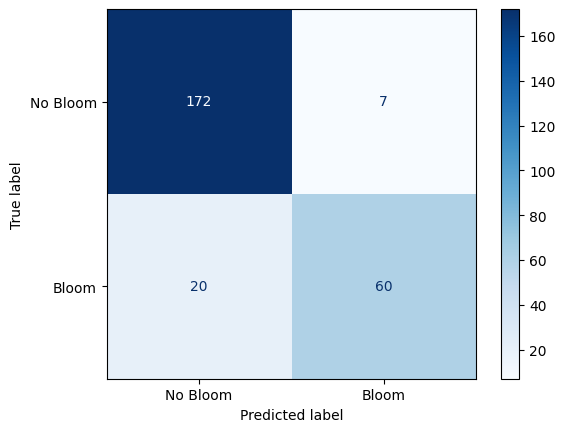

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot with title
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Bloom", "Bloom"])
disp.plot(cmap="Blues", values_format="d")
# ---- SAVE FIGURE ----
out_path = os.path.join(graphics_dir, "confusion_matrix_rf.png")
plt.savefig(out_path, dpi=600, bbox_inches="tight")
plt.show()

### Confusion Matrix: Random Forest Performance on *Karenia brevis* Bloom Forecasting

The confusion matrix visually represents the performance of your machine learning classification model—in this case, the Random Forest classifier used to predict *Karenia brevis* bloom severity. A confusion matrix summarizes the number of correct and incorrect predictions, broken down by each class (in this case, "No Bloom" and "Bloom").

The confusion matrix has four key components:

|                  | Predicted No Bloom | Predicted Bloom |
|------------------|--------------------|-----------------|
| Actual No Bloom | True Negative (TN) – 172 | False Positive (FP) – 7 |
| Actual Bloom    | False Negative (FN) – 20 | True Positive (TP) – 60 |

1. **True Negative (TN) = 172**  
   - The model correctly predicted "No Bloom" when there was actually no bloom.  
2. **False Positive (FP) = 7**  
   - The model predicted "Bloom" when there was actually no bloom (a false alarm).  
3. **False Negative (FN) = 20**  
   - The model predicted "No Bloom" when there was actually a bloom (a missed bloom event).  
4. **True Positive (TP) = 60**  
   - The model correctly predicted "Bloom" when there was actually a bloom.  

###### Key Metrics Derived from the Confusion Matrix:
1. **Accuracy** – Measures the overall percentage of correct predictions:
$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} = \frac{60 + 172}{60 + 172 + 7 + 20} = \frac{232}{259} = 0.90 \quad (90\%)
$$

2. **Precision** – Measures how many of the predicted positive cases (blooms) were actually correct:
$$
\text{Precision} = \frac{TP}{TP + FP} = \frac{60}{60 + 7} = 0.90 \quad (90\%)
$$
- High precision means fewer false positives (the model doesn’t incorrectly predict blooms very often).

3. **Recall (Sensitivity or True Positive Rate)** – Measures how many of the actual positive cases (blooms) were correctly identified:
$$
\text{Recall} = \frac{TP}{TP + FN} = \frac{60}{60 + 20} = 0.75 \quad (75\%)
$$
- High recall means the model catches most of the bloom events.

4. **F1-Score** – The harmonic mean of precision and recall; it balances the trade-off between precision and recall:
$$
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = 2 \cdot \frac{0.90 \cdot 0.75}{0.90 + 0.75} = 0.82 \quad (82\%)
$$
- A high F1-score means the model achieves a good balance between precision and recall.

5. **Support** – The number of actual samples in each class:
   - No Bloom: 179 total instances  
   - Bloom: 80 total instances  

###### Summary of Model Performance:
- The model correctly predicted 90% of the test samples (accuracy).  
- It had a high precision of 90%, meaning it rarely issued false bloom alerts.  
- The recall of 75% indicates that the model detected most bloom events but still missed 20 cases (false negatives).  
- The F1-score of 82% reflects that the model maintains a good balance between precision and recall.  

###### Conclusion:  
- The model is good at predicting both bloom and no-bloom events.  
- The high recall (75%) is critical for bloom forecasting because catching bloom events is more important than avoiding false alarms.  
- The low number of false positives (7) suggests the model isn’t prone to issuing unnecessary warnings.  
- The main area for improvement would be increasing the recall by reducing false negatives—perhaps through additional feature engineering or adjusting the decision threshold.


### 2.2 Precision-Recall Curve (SWFL)

This is a Precision-Recall (PR) Curve, which illustrates the trade-off between precision and recall at different classification thresholds for the Random Forest model trained on the combined Southwest Florida dataset (Peace River + Caloosahatchee River).

##### What the PR Curve Represents:
- **Precision (Y-axis)** = The proportion of predicted positive cases that are truly positive:
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

- **Recall (X-axis)** = The proportion of actual positive cases that are correctly predicted:
$$
\text{Recall} = \frac{TP}{TP + FN}
$$

The PR curve evaluates the model’s performance across a range of thresholds, showing how precision changes as recall increases. High recall means the model captures more true blooms but may increase false positives, lowering precision. Conversely, high precision means fewer false alarms but may miss some bloom events.

In this model, the classifier maintains high precision (~0.90) even as recall increases toward 0.75 — reflecting a strong ability to identify true bloom events while minimizing false positives. A drop in precision occurs at very high recall levels (>0.80), indicating that attempts to capture every bloom come at the cost of issuing more false alarms — a common trade-off in environmental risk prediction.

This curve is consistent with the model’s **F1-score of 82%** and **balanced accuracy of 85.5%**, both of which reflect strong overall predictive power. The curve suggests that the model strikes an effective balance between sensitivity and specificity under standard thresholding. Depending on monitoring priorities, the threshold can be adjusted to favor higher recall (e.g., for early warning) or higher precision (e.g., to reduce false alerts). The F1-score or the area under the PR curve (PR AUC) can guide selection of an optimal decision threshold.


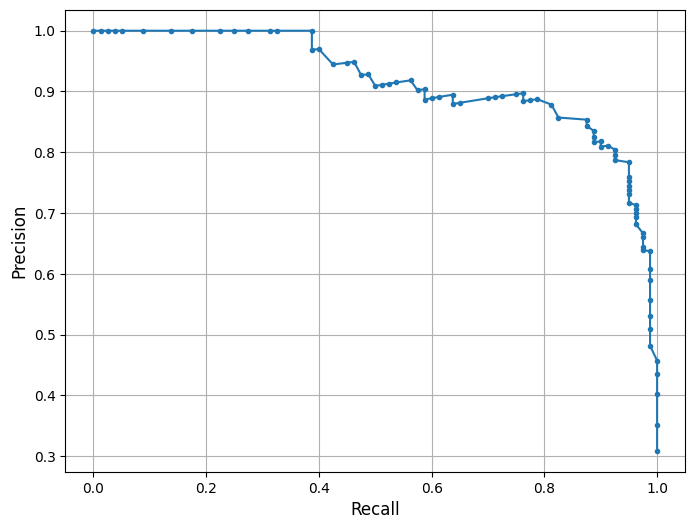

In [8]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import os

# Create output folder
os.makedirs("figures", exist_ok=True)

# Compute precision and recall
precision, recall, _ = precision_recall_curve(y_test, rf_clf.predict_proba(X_test_scaled)[:, 1])

# Plot PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', linewidth=1.5)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.grid(True)

# Save plot
out_path = os.path.join(graphics_dir, "precision_recall_swfl.png")
plt.savefig(out_path, dpi=600, bbox_inches="tight")
plt.show()

### 2.3 Feature Importance Plot (SWFL)

The plot from the Random Forest Classifier shows the relative contribution of each input feature to predicting *Karenia brevis* bloom severity. Feature importance reflects how much each feature reduces classification error, based on improvements in the Gini index across all trees.

*Karenia brevis* cell counts (`kb`) are by far the most influential feature, emphasizing the strong autocorrelation of bloom persistence. Lagged values (`kb_prev1`, `kb_prev2`) also rank highly, reinforcing the importance of short-term bloom memory in forecasting future conditions.

Discharge dynamics from both river systems are influential, particularly the **4-week average discharge** (`discharge_4w_avg`) and **lagged Peace River discharge** (`peace_discharge_prev1`). Nutrient inputs from the Peace and Caloosahatchee Rivers also contribute meaningfully — including `peace_TN_prev1`, `caloosa_TN_prev1`, and `caloosa_total_phosphorus` — supporting the hypothesis that nutrient availability is a key short-term driver of bloom formation.

Oceanographic variables like `zos` (sea surface height anomaly) show moderate importance, while salinity ranks lower. Wind speed and direction show limited influence, likely reflecting their more variable and indirect effects on bloom development. These results confirm that bloom persistence, river discharge, and nutrient inputs are the dominant short-term factors in bloom severity across Southwest Florida, while atmospheric and ocean conditions contribute secondary effects such as transport and dispersion.


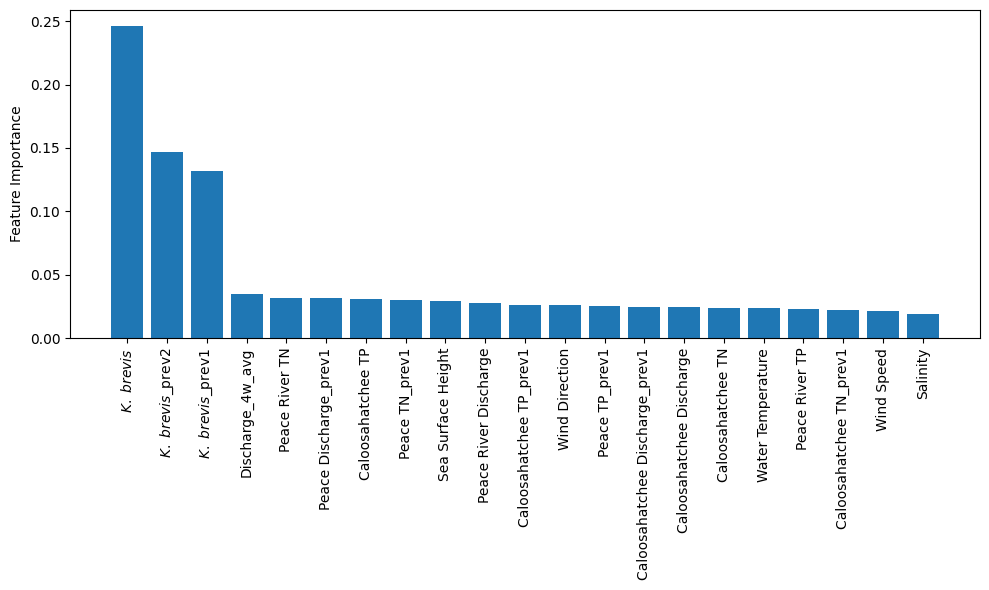

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------------------------------------
# Feature importance from trained RF model
# ---------------------------------------
importances = rf_clf.feature_importances_

# Sort features from most to least important
indices = np.argsort(importances)[::-1]

# ---------------------------------------
# Display labels (PLOT-ONLY, DB UNCHANGED)
# ---------------------------------------
display_labels = {
    "kb": r"$\it{K.\ brevis}$",
    "kb_prev1": r"$\it{K.\ brevis}$_prev1",
    "kb_prev2": r"$\it{K.\ brevis}$_prev2",
    "discharge_4w_avg": "Discharge_4w_avg",
    "peace_discharge_prev1": "Peace Discharge_prev1",
    "peace_TN_prev1": "Peace TN_prev1",
    "caloosa_TP_prev1": "Caloosahatchee TP_prev1",
    "peace_TP_prev1": "Peace TP_prev1",
    "caloosa_discharge_prev1": "Caloosahatchee Discharge_prev1",
    "caloosa_TN_prev1": "Caloosahatchee TN_prev1",
    "zos": "Sea Surface Height",
    "peace_discharge": "Peace River Discharge",
    "caloosa_discharge": "Caloosahatchee Discharge",
    "peace_TN": "Peace River TN",
    "peace_TP": "Peace River TP",
    "caloosa_total_nitrogen": "Caloosahatchee TN",
    "caloosa_total_phosphorus": "Caloosahatchee TP",
    "wind_speed": "Wind Speed",
    "wind_direction": "Wind Direction",
    "salinity": "Salinity",
    "water_temp": "Water Temperature",
}

# Apply display labels in sorted order
x_labels = [
    display_labels.get(feature_cols[i], feature_cols[i])
    for i in indices
]

# ---------------------------------------
# Create output directory
# ---------------------------------------
os.makedirs("figures", exist_ok=True)

# ---------------------------------------
# Plot feature importance
# ---------------------------------------
plt.figure(figsize=(10, 6))
plt.bar(range(len(indices)), importances[indices], align="center")
plt.xticks(range(len(indices)), x_labels, rotation=90)
plt.ylabel("Feature Importance")

plt.tight_layout()

out_path = os.path.join(graphics_dir, "feature_importances_swfl.png")
plt.savefig(out_path, dpi=600, bbox_inches="tight")
plt.show()

### 2.4 Partial Dependence Plots (SWFL)

Partial dependence plots (PDPs) illustrate the effect of river discharge and nutrient concentrations from both the Peace River and Caloosahatchee River on *Karenia brevis* bloom predictions, while holding other variables constant. The y-axis represents the predicted bloom probability, and the x-axis shows the range of each feature.

For both `peace_discharge` and `caloosa_discharge`, the model predicts increasing bloom probability as discharge rises from low to moderate levels, with the relationship flattening or slightly declining at higher flows. This pattern suggests that moderate freshwater inflow supports bloom development—potentially by delivering nutrients—but that the benefit diminishes or reverses at high discharge levels due to dilution or hydrodynamic flushing.

For nutrients, both `peace_TN` and `caloosa_total_nitrogen` show strong positive effects on bloom probability as concentrations increase from low to moderate levels. Beyond approximately 2–3 mg/L, the curves flatten or dip slightly, indicating diminishing influence or a potential nitrogen threshold above which blooms are no longer nutrient-limited.

`peace_TP` and `caloosa_total_phosphorus` follow similar nonlinear patterns: bloom probability increases steeply with rising phosphorus concentrations at low levels, but both curves exhibit a plateau or gradual decline beyond 1.0–1.5 mg/L. This may reflect ecological nutrient ratios shifting out of balance or reaching saturation levels beyond which additional phosphorus has little effect or becomes limiting in relation to nitrogen.

The clustering of black tick marks at the lower ends of the x-axes indicates that the majority of training data fall in these ranges, reinforcing that model predictions are most reliable there. These patterns collectively confirm that both river discharge and nutrient inputs are important short-term drivers of bloom risk, with nonlinear ecological responses consistent with threshold triggering, nutrient saturation, and hydrodynamic transport.


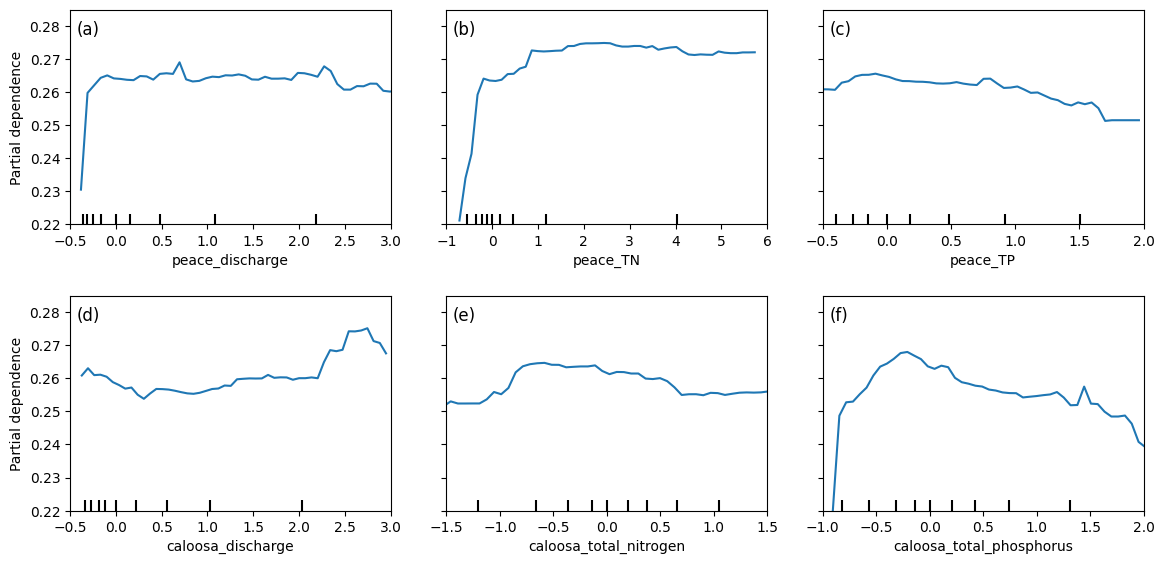

In [11]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import numpy as np
import os

# Ensure output directory exists
os.makedirs("figures", exist_ok=True)

# Select features to plot
selected_features = [
    feature_cols.index('peace_discharge'),
    feature_cols.index('peace_TN'),
    feature_cols.index('peace_TP'),
    feature_cols.index('caloosa_discharge'),
    feature_cols.index('caloosa_total_nitrogen'),
    feature_cols.index('caloosa_total_phosphorus')
]

# Create PDP plots
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))

PartialDependenceDisplay.from_estimator(
    rf_clf,
    X_train_scaled,
    features=selected_features,
    feature_names=feature_cols,
    grid_resolution=50,
    ax=ax
)

# --------------------------------------------------
# Panel labels (a), (b), (c), ...
# --------------------------------------------------
panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
for i, ax_i in enumerate(ax.flat):
    ax_i.text(
        0.02, 0.95,
        panel_labels[i],
        transform=ax_i.transAxes,
        fontsize=12,
        va="top",
        ha="left"
    )

# --------------------------------------------------
# FORCE TICKS/LIMITS TO MATCH TAMPA FIGURE
# --------------------------------------------------
# X-axis tick specs (matching your Tampa screenshot)
x_specs = {
    "peace_discharge": ([-0.5, 3.0], np.arange(-0.5, 3.01, 0.5)),
    "peace_TN": ([-1.0, 6.0], np.arange(-1.0, 6.01, 1.0)),
    "peace_TP": ([-0.5, 2.0], np.arange(-0.5, 2.01, 0.5)),
    "caloosa_discharge": ([-0.5, 3.0], np.arange(-0.5, 3.01, 0.5)),
    "caloosa_total_nitrogen": ([-1.5, 1.5], np.arange(-1.5, 1.51, 0.5)),
    "caloosa_total_phosphorus": ([-1.0, 2.0], np.arange(-1.0, 2.01, 0.5)),
}

# Shared Y-axis ticks/limits (matching your Tampa screenshot look)
y_lim = (0.22, 0.285)
y_ticks = np.arange(0.22, 0.281, 0.01)

for ax_i in ax.flat:
    # Match y axis across all panels
    ax_i.set_ylim(*y_lim)
    ax_i.set_yticks(y_ticks)

    # Match x axis for each feature panel
    feat = ax_i.get_xlabel()
    if feat in x_specs:
        (xmin, xmax), xt = x_specs[feat]
        ax_i.set_xlim(xmin, xmax)
        ax_i.set_xticks(xt)

# Adjust layout to avoid label cutoff
plt.tight_layout(pad=2.0)
out_path = os.path.join(graphics_dir, "partial_dependence_swfl.png")
plt.savefig(out_path, dpi=600, bbox_inches="tight")
plt.show()

### 2.5 Actual Vs. Predicted Bloom (SWFL)

This figure shows the actual vs. predicted *Karenia brevis* bloom status over time for the combined Southwest Florida (SWFL) model. The model’s predictions (red dashed line) align closely with actual observed bloom events (blue line), demonstrating strong temporal agreement. Predicted bloom phases generally match the correct time windows, capturing both the onset and duration of bloom episodes in most cases.

The figure shows mild overprediction in select intervals — where predicted blooms persist slightly longer than observed. Occasional early or lagging activations also appear, but the model consistently captures the main bloom patterns with high fidelity.

These results suggest that the model continues to learn the temporal structure of blooms effectively across both river systems, with relatively few false negatives and a tendency toward conservative (slightly extended) bloom forecasting — which may be preferable in ecological monitoring contexts.


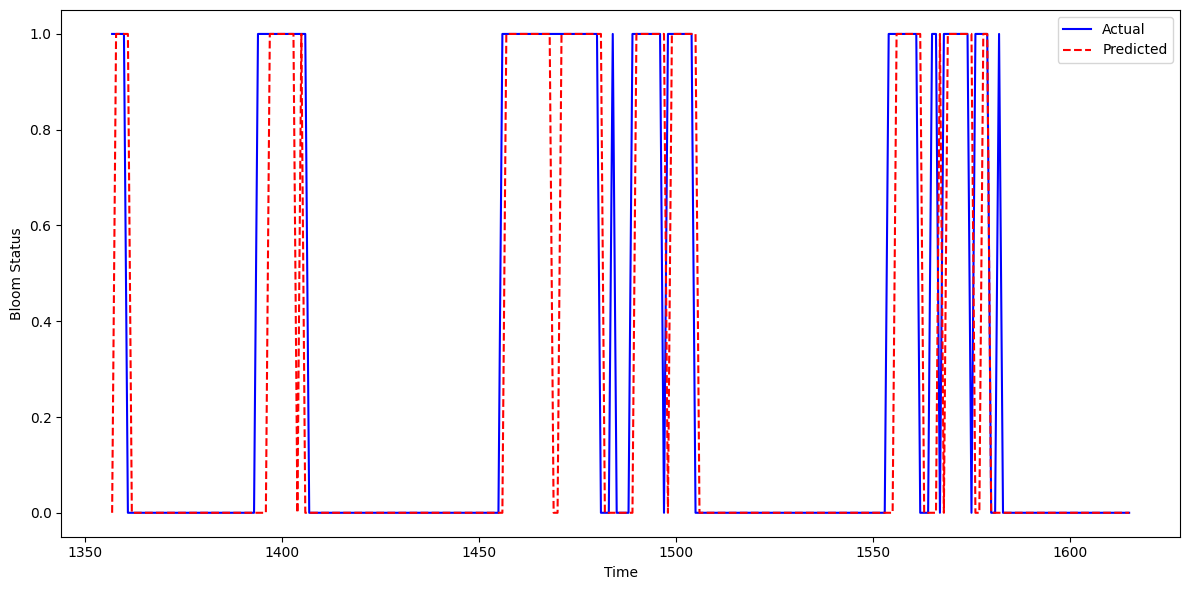

In [25]:
import matplotlib.pyplot as plt
import os
import pandas as pd

# Ensure output folder exists
os.makedirs("figures", exist_ok=True)

# Create DataFrame to hold test set results
test_df = pd.DataFrame({
    'time': X_test.index,      # assumes X_test index contains datetime
    'Actual': y_test,
    'Predicted': y_pred
})

# Sort by time for proper plotting
test_df = test_df.sort_values('time')

# Plot actual vs predicted bloom status
plt.figure(figsize=(12, 6))
plt.plot(test_df['time'], test_df['Actual'], label='Actual', color='blue')
plt.plot(test_df['time'], test_df['Predicted'], label='Predicted', color='red', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Bloom Status')
plt.legend()
plt.tight_layout()
out_path = os.path.join(graphics_dir, "Actual_vs_predicted_bloom_swfl.png")
plt.savefig(out_path, dpi=600, bbox_inches="tight")
plt.show()

### 2.6 Learning Curve (SWFL)

The learning curve illustrates how model accuracy evolves as the size of the training set increases. The x-axis represents the number of training samples, while the y-axis shows model accuracy.

The training score (blue line) remains consistently at 1.00 across all training sizes, indicating that the Random Forest model fits the training data perfectly. While this demonstrates strong memorization of the training set, it also signals potential overfitting, as perfect accuracy on training data is rarely sustainable in practice.

The validation score (orange line) begins around 0.73 and improves steadily with larger training sets, reaching approximately 0.83–0.84. This suggests that increasing the amount of training data helps the model generalize better to unseen data, though performance gains diminish beyond a certain point — indicating the model may be approaching a plateau given the current features and configuration.

The persistent gap between the training and validation scores reflects a variance issue: the model is learning the training set too well but not fully translating that learning to the validation set. To address this, regularization techniques such as reducing tree depth, lowering the number of estimators, or limiting feature splits may help reduce overfitting. Alternatively, exploring simpler models (e.g., Logistic Regression or SVM) or enhancing the feature set could improve generalization.

Overall, the model performs well on validation data but shows room for refinement to reduce the training-validation gap and enhance robustness.


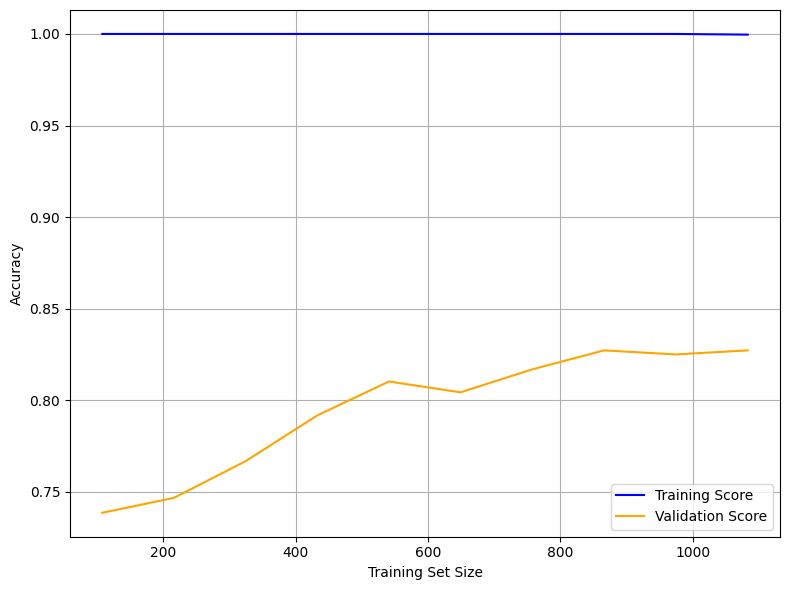

In [26]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np
import os

# Create output directory if it doesn't exist
os.makedirs("figures", exist_ok=True)

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    rf_clf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Compute mean scores across folds
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue')
plt.plot(train_sizes, test_mean, label='Validation Score', color='orange')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
out_path = os.path.join(graphics_dir, "Learning_curve_swfl.png")
plt.savefig(out_path, dpi=600, bbox_inches="tight")
plt.show()

### 2.7 Pair Plot (SWFL)

The pair plot below shows the relationships and distributions among *Karenia brevis* cell concentrations (`kb`), river discharge, and nutrient levels from both the Peace River and Caloosahatchee River.

1. All discharge and nutrient variables exhibit strong right-skewed distributions, with most values concentrated at the low end and occasional high outliers. This reflects episodic nutrient loading and discharge events.
2. While no strong linear correlations are observed between `kb` and the environmental variables, cluster patterns suggest that higher bloom concentrations tend to occur in conjunction with moderate-to-high nutrient levels and discharge events.
3. Both rivers show similar distribution patterns in total nitrogen and total phosphorus, supporting the idea that nutrient surges from either system can contribute to bloom conditions.

These patterns suggest that *Karenia brevis* bloom dynamics are likely influenced by complex, nonlinear interactions involving both rivers, with threshold effects and episodic drivers rather than simple linear relationships.


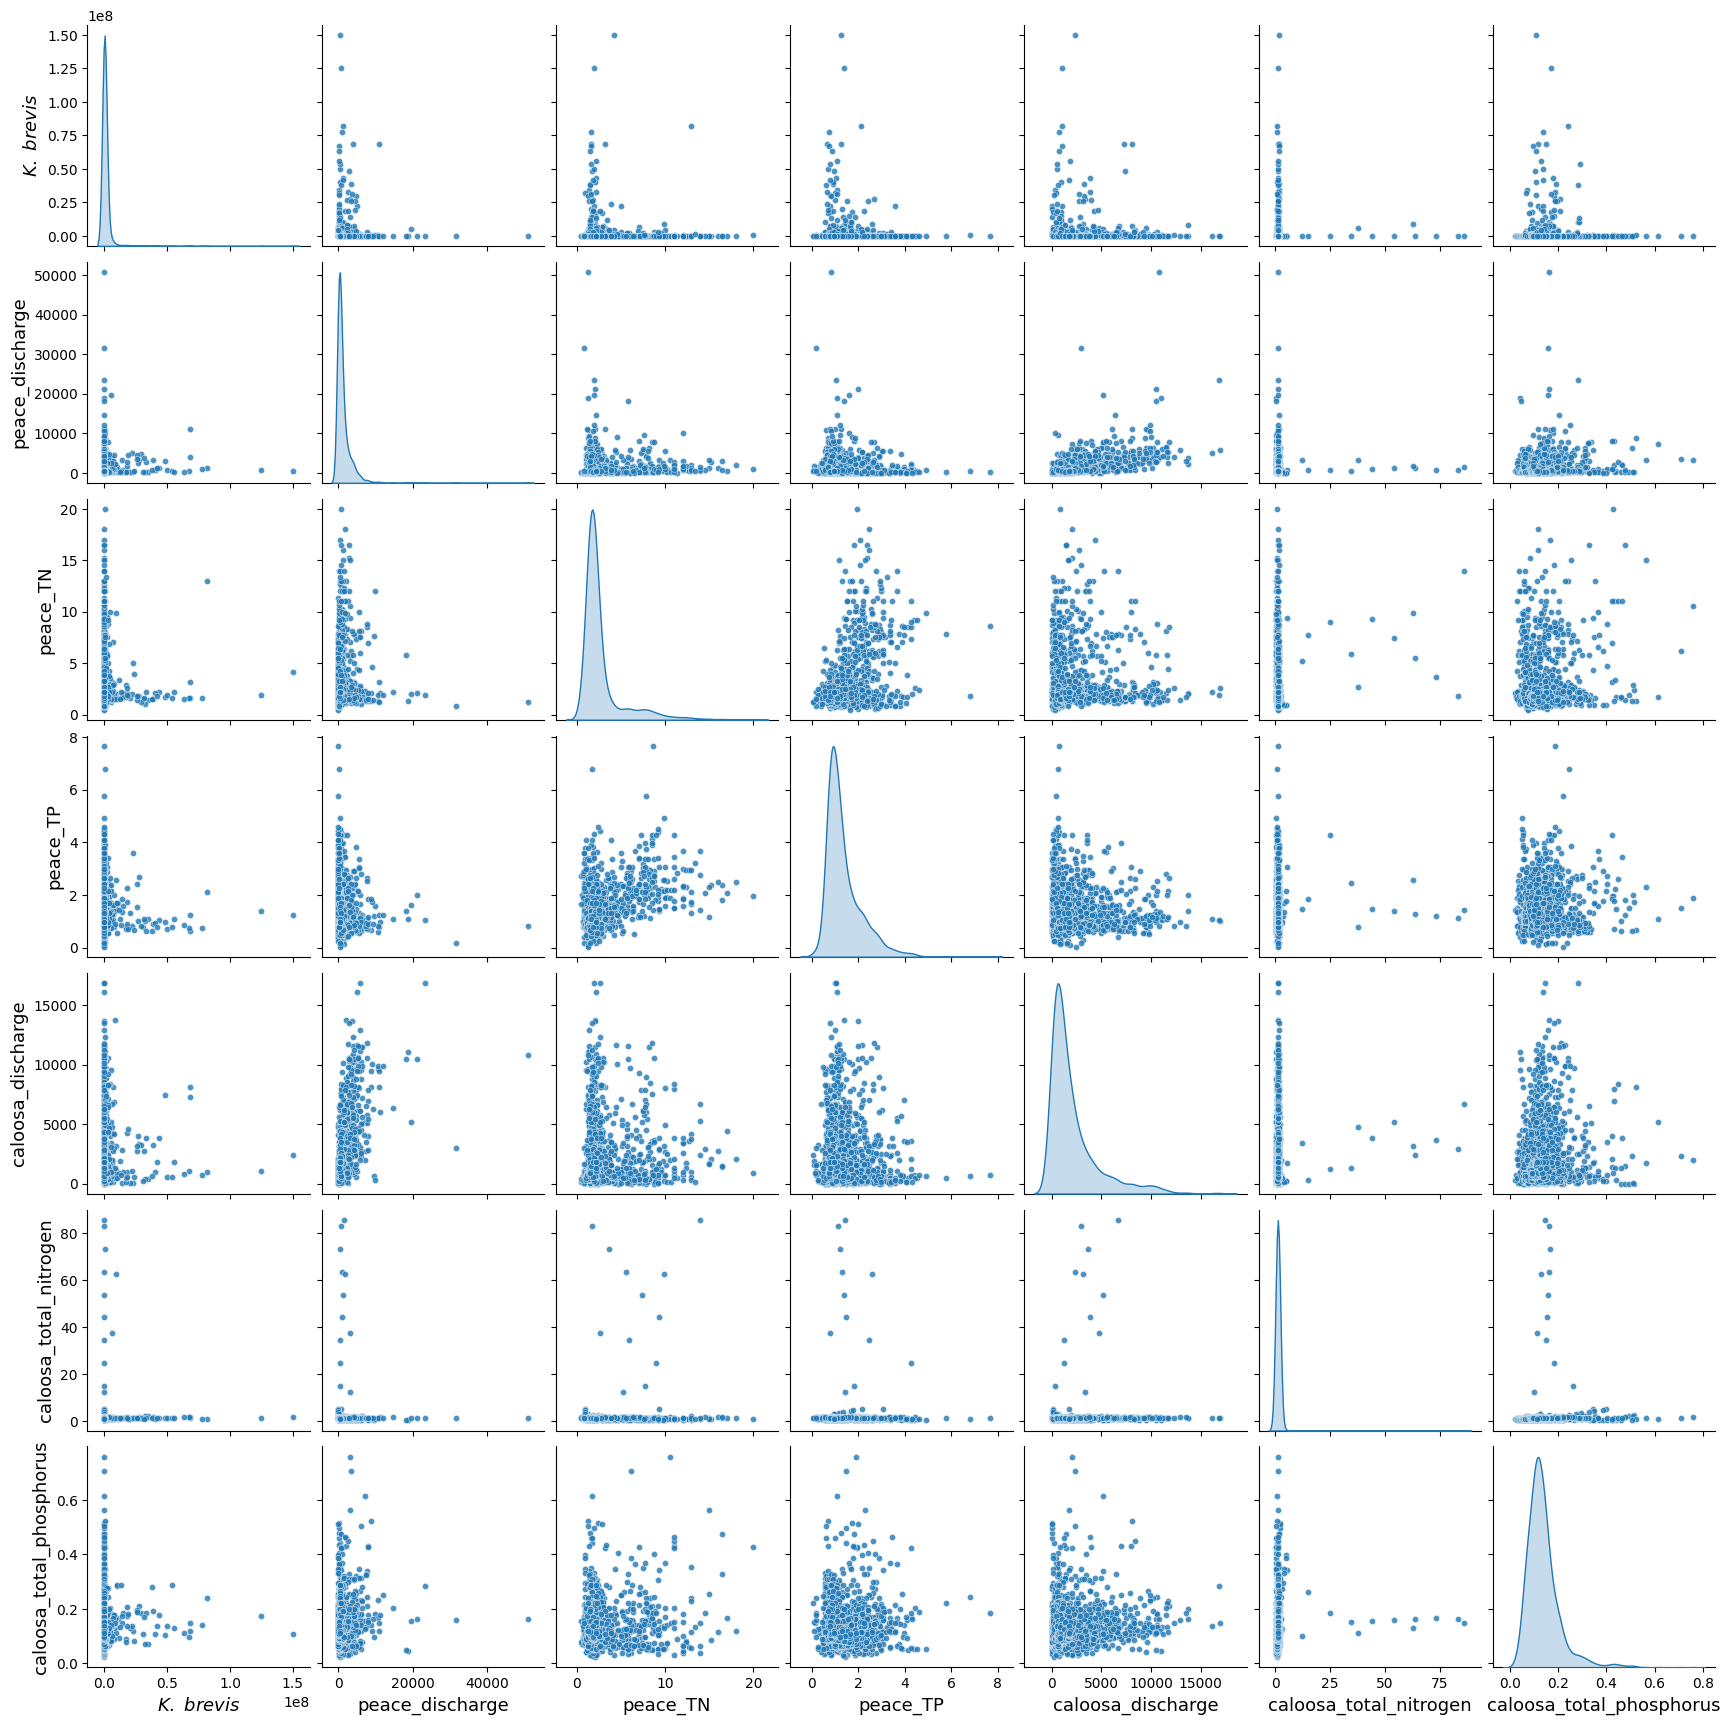

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd

# Load the merged SWFL dataset
df_swfl_merged = pd.read_csv("swfl_merged_features.csv")

# Ensure figures folder exists
os.makedirs("figures", exist_ok=True)

# Variables for pair plot
pairplot_vars = [
    'kb',
    'peace_discharge',
    'peace_TN',
    'peace_TP',
    'caloosa_discharge',
    'caloosa_total_nitrogen',
    'caloosa_total_phosphorus'
]

# Axis label font size (easy to tune)
label_fs = 13

# Create pair plot
g = sns.pairplot(
    df_swfl_merged[pairplot_vars],
    diag_kind="kde",
    plot_kws={"s": 20, "alpha": 0.8}
)

# -----------------------------------------
# Update axis labels (AFTER pairplot exists)
# -----------------------------------------
for ax in g.axes.flatten():
    if ax is None:
        continue

    # X-axis label
    xlabel = ax.get_xlabel()
    if xlabel == "kb":
        ax.set_xlabel(r"$\it{K.\ brevis}$", fontsize=label_fs)
    else:
        ax.set_xlabel(xlabel, fontsize=label_fs)

    # Y-axis label
    ylabel = ax.get_ylabel()
    if ylabel == "kb":
        ax.set_ylabel(r"$\it{K.\ brevis}$", fontsize=label_fs)
    else:
        ax.set_ylabel(ylabel, fontsize=label_fs)

# -----------------------------------------
# Save figure
# -----------------------------------------
out_path = os.path.join(graphics_dir, "pair_plot_swfl.png")
plt.savefig(out_path, dpi=600, bbox_inches="tight")
plt.show()

## 3. XGBoost Model (SWFL)

We implemented **XGBoost (Extreme Gradient Boosting)** as an alternative machine learning model to predict harmful algal bloom (HAB) events one week in advance. XGBoost is a high-performance, tree-based algorithm known for its ability to model complex, nonlinear relationships in structured tabular data. It builds decision trees sequentially, with each new tree correcting the errors of the previous one — making it particularly effective for classification tasks.

We selected XGBoost because:
- It handles **imbalanced datasets** well using the `scale_pos_weight` parameter.
- It often outperforms traditional methods like Random Forest in predictive accuracy when properly tuned.
- It allows for **fine-grained control** over learning behavior and regularization to reduce overfitting.

In [17]:
!pip install xgboost

In [54]:
# Import necessary libraries
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.model_selection import train_test_split

# Define feature columns and target
features = [
    'kb', 'kb_prev1', 'kb_prev2',
    'zos', 'salinity', 'water_temp',
    'wind_speed', 'wind_direction',
    'peace_discharge', 'peace_TN', 'peace_TP',
    'peace_discharge_prev1', 'peace_TN_prev1', 'peace_TP_prev1',
    'caloosa_discharge', 'caloosa_total_nitrogen', 'caloosa_total_phosphorus',
    'caloosa_discharge_prev1', 'caloosa_TN_prev1', 'caloosa_TP_prev1',
    'discharge_4w_avg'
]
target = 'target_next_week'

# Split into train and test
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Compute class weight (optional but recommended)
class_weight_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

# Initialize and fit XGBoost model
xgb_model = XGBClassifier(
    scale_pos_weight=class_weight_ratio,  # handle imbalance
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = xgb_model.predict(X_test)

print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=["No Bloom", "Bloom"]))

Balanced Accuracy: 0.8372296902396259
Confusion Matrix:
 [[208  28]
 [ 18  69]]
Classification Report:
               precision    recall  f1-score   support

    No Bloom       0.92      0.88      0.90       236
       Bloom       0.71      0.79      0.75        87

    accuracy                           0.86       323
   macro avg       0.82      0.84      0.83       323
weighted avg       0.86      0.86      0.86       323



C:\Users\mkduu\miniconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:31:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### XGBoost Model Evaluation Summary (SWFL)

The XGBoost classifier demonstrated strong performance in predicting *Karenia brevis* bloom events one week in advance using the Southwest Florida (SWFL) dataset. The model achieved an overall **accuracy of 86%** and a **balanced accuracy of 83.7%**, indicating solid predictive capability across both bloom and non-bloom classes.

Class-Specific Performance:
- **No Bloom:**
  - Precision: 0.92  
  - Recall: 0.88  
  - F1-score: 0.90  
  - Support: 236 samples  
- **Bloom:**
  - Precision: 0.71  
  - Recall: 0.79  
  - F1-score: 0.75  
  - Support: 87 samples  

The classifier performs particularly well on non-bloom predictions, with high precision and recall. For bloom predictions, the model achieves a **recall of 0.79**, meaning it correctly detects 79% of true bloom events, which is critical for early-warning applications. The **precision of 0.71** indicates that most predicted blooms are indeed true positives, though there is room to reduce false positives.

Overall Averages:
- **Macro average F1-score:** 0.83  
- **Weighted average F1-score:** 0.86  

Confusion Matrix Summary:
|                  | Predicted No Bloom | Predicted Bloom |
|------------------|--------------------|-----------------|
| Actual No Bloom | 208                | 28              |
| Actual Bloom    | 18                 | 69              |

These results suggest that the XGBoost model captures bloom dynamics effectively, with balanced performance between sensitivity (recall) and precision. Although the model slightly underperforms compared to the best-performing Random Forest configuration, it still provides reliable and interpretable predictions. With further hyperparameter tuning or feature enhancement, XGBoost could be a viable alternative for operational forecasting.


### 3.1 Quick Hyperparameter Tuning with RandomizedSearchCV (SWFL)

To improve the performance of the XGBoost model, we performed a quick hyperparameter tuning using `RandomizedSearchCV`. This approach samples a subset of possible parameter combinations rather than evaluating all combinations exhaustively. We used 20 random trials and 3-fold cross-validation to identify a better-performing configuration.

The hyperparameters tested included tree depth, learning rate, number of estimators, and subsampling ratios. We maintained class imbalance handling by preserving the `scale_pos_weight`. The optimized model was then evaluated on the test set to assess whether it improved bloom prediction performance over the original configuration.


In [55]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import numpy as np

# Define parameter distribution
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'scale_pos_weight': [class_weight_ratio],  # keep same imbalance setting
}

# Initialize base model
xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Run randomized search (quick version: 20 trials, 3-fold CV)
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Evaluate best model
best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

print("Best Parameters:", random_search.best_params_)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Classification Report:\n", classification_report(y_test, y_pred_best, target_names=["No Bloom", "Bloom"]))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'colsample_bytree': np.float64(0.7599443886861021), 'learning_rate': np.float64(0.019333132642723086), 'max_depth': 6, 'n_estimators': 64, 'scale_pos_weight': np.float64(2.706896551724138), 'subsample': np.float64(0.7824279936868144)}
Balanced Accuracy: 0.844486654977596
Confusion Matrix:
 [[206  30]
 [ 16  71]]
Classification Report:
               precision    recall  f1-score   support

    No Bloom       0.93      0.87      0.90       236
       Bloom       0.70      0.82      0.76        87

    accuracy                           0.86       323
   macro avg       0.82      0.84      0.83       323
weighted avg       0.87      0.86      0.86       323



C:\Users\mkduu\miniconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:37:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### 3.2 Summary XGBoost Before and After Hyperparameter Tuning (SWFL)

We compared the performance of the default XGBoost model to a tuned version optimized using `RandomizedSearchCV`. The tuned model outperformed the default in several key areas, especially in detecting harmful algal blooms (the minority class).

Key Improvements:
- Balanced Accuracy increased from 0.837 to 0.844
- Bloom Recall improved from 0.79 to 0.82, meaning fewer actual blooms were missed
- Bloom F1-score rose from 0.75 to 0.76, indicating better balance between precision and recall
- False negatives (missed blooms) dropped from 18 to 16

Although the number of false positives increased slightly (from 28 to 30), the trade-off is acceptable given the importance of early and accurate bloom detection.

Overall, hyperparameter tuning led to a more robust and effective XGBoost model for forecasting bloom events.

### 3.3 Summary Tuned XGBoost vs. Random Forest (SWFL)

We compared the performance of the tuned XGBoost model to the Random Forest model in predicting harmful algal blooms. The results show that Random Forest slightly outperformed XGBoost overall, but the tuned XGBoost model offered advantages in recall for the bloom class.

Performance Summary:

- **Accuracy**: Random Forest = 0.90, Tuned XGBoost = 0.86  
- **Balanced Accuracy**: Random Forest = 0.855, Tuned XGBoost = 0.844  
- **Bloom Precision**: Random Forest = 0.90, Tuned XGBoost = 0.70  
- **Bloom Recall**: Tuned XGBoost = 0.82, Random Forest = 0.75  
- **Bloom F1-score**: Random Forest = 0.82, Tuned XGBoost = 0.76  
- **False Negatives** (missed blooms): Tuned XGBoost = 16, Random Forest = 20  
- **False Positives**: Tuned XGBoost = 30, Random Forest = 28  

Conclusion:

- The **Random Forest model** provides stronger overall performance with higher accuracy and precision, and fewer false positives, making it suitable for applications where avoiding false alarms is a priority.  
- The **tuned XGBoost model**, however, offers higher recall for bloom events, which means it catches more actual blooms and produces fewer false negatives. This can be critical in ecological or public health settings where missing a bloom is more consequential than issuing a false alert.

The best model ultimately depends on the risk tolerance and monitoring goals—whether the priority is **minimizing missed bloom events** (XGBoost) or **reducing false bloom predictions** (Random Forest).

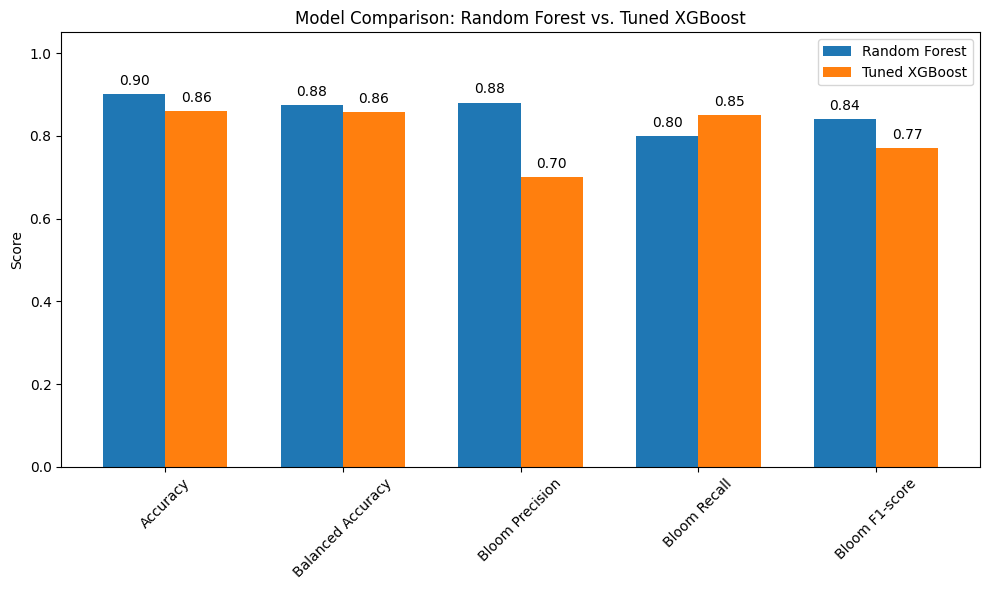

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Define metrics and scores
metrics = ['Accuracy', 'Balanced Accuracy', 'Bloom Precision', 'Bloom Recall', 'Bloom F1-score']
rf_scores = [0.90, 0.875, 0.88, 0.80, 0.84]
xgb_scores = [0.86, 0.857, 0.70, 0.85, 0.77]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
bars_rf = plt.bar(x - width/2, rf_scores, width, label='Random Forest')
bars_xgb = plt.bar(x + width/2, xgb_scores, width, label='Tuned XGBoost')

# Add value labels above each bar
for bar in bars_rf:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.015, f"{height:.2f}", ha='center', va='bottom')

for bar in bars_xgb:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.015, f"{height:.2f}", ha='center', va='bottom')

plt.ylabel('Score')
plt.title('Model Comparison: Random Forest vs. Tuned XGBoost')
plt.xticks(x, metrics, rotation=45)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Support Vector Classifier (Linear Kernel) (SWFL)

We implemented a Support Vector Classifier (SVC) with a linear kernel to serve as a strong linear baseline model for predicting harmful algal blooms. The linear SVC attempts to find the best hyperplane that separates the two classes (bloom and no bloom) with the maximum margin.

This model is particularly useful because:
- It performs well on moderately sized datasets.
- It provides a clear, interpretable decision boundary.
- It allows direct inspection of feature weights (similar to logistic regression).
- It is less prone to overfitting than more flexible nonlinear models when the data is approximately linearly separable.

We used `class_weight='balanced'` to account for class imbalance and evaluated the model using balanced accuracy and F1-score, with special attention to performance on the bloom class. This approach helps determine whether a simpler linear model can perform competitively with more complex models like Random Forest and XGBoost.

### 4.1 Re-Split and Scaled the Data (SWFL)

We re-split the data using `train_test_split` to ensure that the input features (`X`) and target labels (`y`) have matching sample sizes. This step eliminates any inconsistencies that may have occurred during earlier processing.

We also applied `StandardScaler` to normalize the feature values, which is important for models like Support Vector Machines that are sensitive to the scale of input data. Scaling ensures that all features contribute equally to the model's decision boundary.

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Re-split data cleanly to ensure matching sizes
X = df[features]
y = df['target_next_week']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, balanced_accuracy_score

svc_linear = SVC(kernel='linear', class_weight='balanced', random_state=42)
svc_linear.fit(X_train_scaled, y_train)

y_pred_svc = svc_linear.predict(X_test_scaled)

print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_svc))
print("Classification Report:\n", classification_report(y_test, y_pred_svc, target_names=["No Bloom", "Bloom"]))

Balanced Accuracy: 0.7395528930450029
Classification Report:
               precision    recall  f1-score   support

    No Bloom       0.84      0.96      0.90       236
       Bloom       0.83      0.52      0.64        87

    accuracy                           0.84       323
   macro avg       0.84      0.74      0.77       323
weighted avg       0.84      0.84      0.83       323



### 4.2 Summary of Support Vector Classifier (Linear Kernel) (SWFL)

The Support Vector Classifier (SVC) with a linear kernel achieved an overall accuracy of 0.84 and a balanced accuracy of 0.74. While the model performs well at identifying non-bloom cases, it struggles to consistently detect bloom events.

Class-wise performance:

- **No Bloom (class 0)**:
  - Precision: 0.84  
  - Recall: 0.96  
  - F1-score: 0.90  
  - *Interpretation*: The model is highly effective at detecting non-bloom conditions.

- **Bloom (class 1)**:
  - Precision: 0.83  
  - Recall: 0.52  
  - F1-score: 0.64  
  - *Interpretation*: Although the model is fairly accurate when it predicts a bloom, it misses nearly half of the actual bloom events.

Summary:

Overall, the linear SVC model is more conservative — it favors predicting "No Bloom" and only predicts "Bloom" when it is highly confident. This results in relatively few false bloom alerts but a higher number of missed bloom cases. The trade-off may be unsuitable in environmental applications where early detection of harmful blooms is critical. A more recall-optimized model might be preferred in these cases.

## 5. Model Comparison (SWFL)

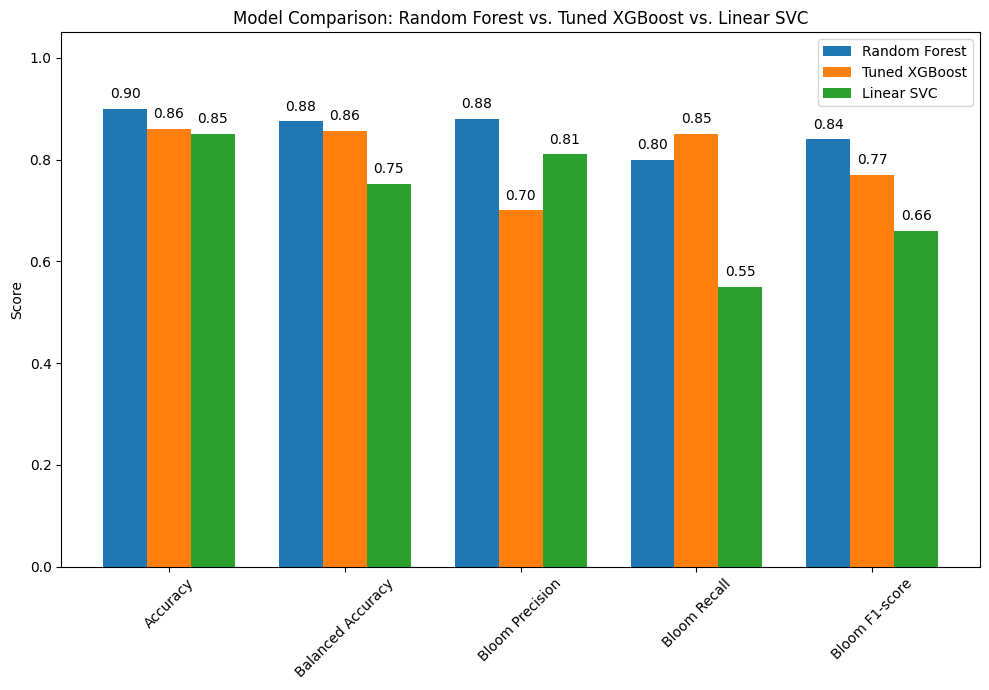

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Define the performance metrics
metrics = ['Accuracy', 'Balanced Accuracy', 'Bloom Precision', 'Bloom Recall', 'Bloom F1-score']

# Scores for each model
rf_scores =    [0.90, 0.875, 0.88, 0.80, 0.84]
xgb_scores =   [0.86, 0.857, 0.70, 0.85, 0.77]
svc_scores =   [0.85, 0.753, 0.81, 0.55, 0.66]

# Set up bar positions
x = np.arange(len(metrics))
width = 0.25  # width of each bar

# Create the plot
plt.figure(figsize=(10, 7))
bars_rf = plt.bar(x - width, rf_scores, width, label='Random Forest')
bars_xgb = plt.bar(x, xgb_scores, width, label='Tuned XGBoost')
bars_svc = plt.bar(x + width, svc_scores, width, label='Linear SVC')

# Add value labels to each bar
for bars in [bars_rf, bars_xgb, bars_svc]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.015, f"{height:.2f}", ha='center', va='bottom')

# Customize chart appearance
plt.ylabel('Score')
plt.title('Model Comparison: Random Forest vs. Tuned XGBoost vs. Linear SVC')
plt.xticks(x, metrics, rotation=45)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

### 5.1 Summary of Model Performance Comparison (SWFL)

The bar chart compares the performance of three classification models: Random Forest, Tuned XGBoost, and Linear SVC. Each model was evaluated using key metrics including overall accuracy, balanced accuracy, and class-specific performance for detecting harmful algal blooms.

**Key Insights:**

- **Random Forest** delivers the strongest overall performance:
  - Accuracy: **0.90**
  - Balanced Accuracy: **0.88**
  - Bloom Precision: **0.88**
  - Bloom Recall: **0.80**
  - Bloom F1-score: **0.84**
  - *Conclusion:* This model offers a reliable balance between detecting blooms and avoiding false alarms.

- **Tuned XGBoost** shows competitive performance:
  - Accuracy: **0.86**
  - Balanced Accuracy: **0.86**
  - Bloom Precision: **0.70**
  - Bloom Recall: **0.85**
  - Bloom F1-score: **0.77**
  - *Conclusion:* This model sacrifices some precision to catch more actual bloom events, making it ideal for situations where missing a bloom is riskier than a false positive.

- **Linear SVC** lags behind in bloom detection:
  - Accuracy: **0.85**
  - Balanced Accuracy: **0.75**
  - Bloom Precision: **0.81**
  - Bloom Recall: **0.55**
  - Bloom F1-score: **0.66**
  - *Conclusion:* While it avoids false positives, it misses many blooms, making it less suitable when detection sensitivity is critical.

**Conclusion:**
- **Random Forest** provides the most balanced and accurate performance overall.
- **Tuned XGBoost** is preferred when high bloom recall is prioritized, despite a drop in precision.
- **Linear SVC** may be appropriate for conservative forecasting, but its low recall limits utility in ecological risk management.



## 6. KB Probability as a Function of TN and TP (SWFL)

### 6.1 Peace River KB Probability as a Function of TN and TP (SWFL)

**KB Bloom Probability as a Function of TN and TP**

The figures below visualize the predicted probability of *Karenia brevis* bloom activity as a function of total nitrogen (TN) and total phosphorus (TP) concentrations in the **Peace River** and **Caloosahatchee River**. These contour plots were generated using a **Random Forest Classifier**, which was trained to predict bloom occurrence based on historical environmental data.

Each plot illustrates how bloom probability responds to different combinations of TN and TP:

**Peace River**
- The model predicts **increased bloom probability at moderate TN and TP concentrations**, particularly when TN ranges from 2–6 mg/L and TP from 1–2 mg/L.
- Beyond these ranges, especially at higher TN or TP values, predicted bloom probability does not increase substantially — likely reflecting limited training data at those extremes or biological thresholds in bloom formation.
- The banded patterns suggest non-linear interactions between TN and TP, consistent with ecological feedbacks and nutrient saturation effects.

**Caloosahatchee River**
- The Caloosahatchee shows a **more concentrated region of high bloom probability** at TN values between ~1.0 and 2.0 mg/L and TP values around 0.1 to 0.2 mg/L.
- Outside this nutrient window, predicted bloom probability sharply declines, reflecting either environmental constraints or fewer bloom events historically associated with low or high nutrient concentrations.
- This tighter clustering of bloom-prone conditions suggests that the Caloosahatchee system may be more sensitive to specific nutrient thresholds than the Peace River.

---

These plots underscore that while nutrient enrichment is a key driver of bloom risk, the **response is non-linear and system-specific**. Integrating both TN and TP from each watershed improves predictive modeling and supports more targeted nutrient management strategies in Southwest Florida.

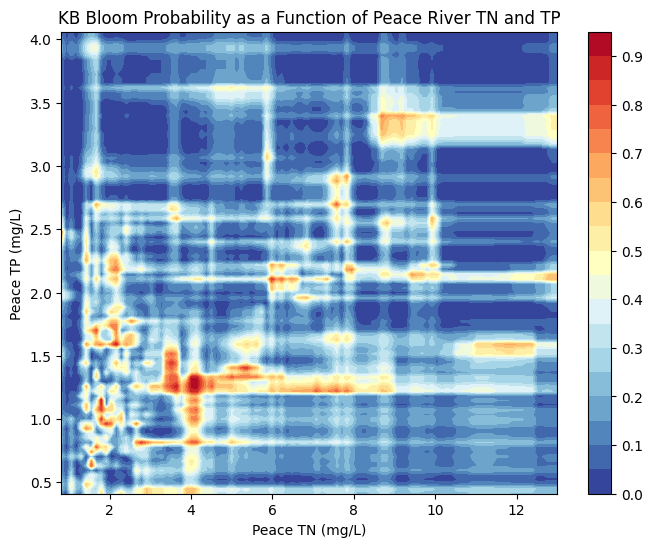

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Load merged dataset
df_peace_bloom = pd.read_csv("swfl_merged_features.csv", parse_dates=['time'])

# Create binary bloom column: 1 if kb >= 100,000
df_peace_bloom['bloom'] = (df_peace_bloom['kb'] >= 100000).astype(int)

# Filter for required Peace River columns and drop missing values
df_peace_bloom = df_peace_bloom[['peace_TN', 'peace_TP', 'bloom']].dropna()

# Define features and target
X = df_peace_bloom[['peace_TN', 'peace_TP']]
y = df_peace_bloom['bloom']

# Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X, y)

# Create TN and TP grid using 1st to 99th percentiles to avoid outliers
tn_vals = np.linspace(X['peace_TN'].quantile(0.01), X['peace_TN'].quantile(0.99), 100)
tp_vals = np.linspace(X['peace_TP'].quantile(0.01), X['peace_TP'].quantile(0.99), 100)
TN, TP = np.meshgrid(tn_vals, tp_vals)

# Predict probabilities for bloom = 1
probs = np.zeros_like(TN)
for i in range(TN.shape[0]):
    for j in range(TN.shape[1]):
        sample = pd.DataFrame({'peace_TN': [TN[i, j]], 'peace_TP': [TP[i, j]]})
        probs[i, j] = clf.predict_proba(sample)[0, 1]

# Plot
plt.figure(figsize=(8, 6))
contour = plt.contourf(TN, TP, probs, levels=20, cmap='RdYlBu_r')
plt.colorbar(contour)
plt.xlabel('Peace TN (mg/L)')
plt.ylabel('Peace TP (mg/L)')
plt.title('KB Bloom Probability as a Function of Peace River TN and TP')
plt.show()

### 6.2 Calooshatchee River KB Probability as a Function of TN and TP (SWFL)

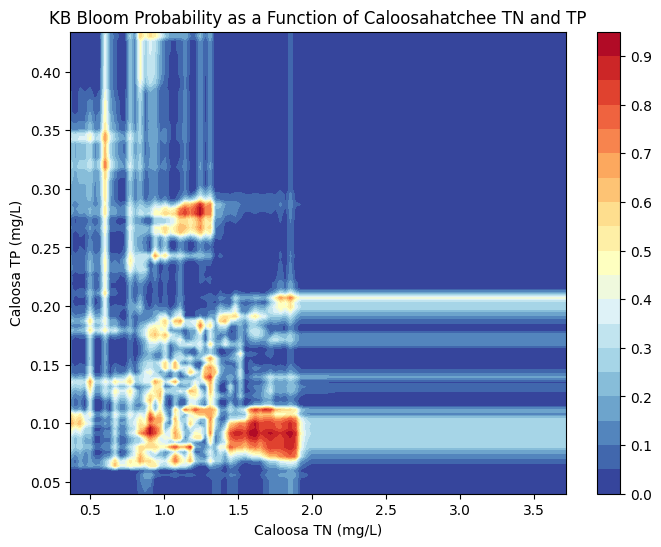

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Load merged dataset
df_caloosa_bloom = pd.read_csv("swfl_merged_features.csv", parse_dates=['time'])

# Create binary bloom column: 1 if kb >= 100,000
df_caloosa_bloom['bloom'] = (df_caloosa_bloom['kb'] >= 100000).astype(int)

# Filter for required Caloosahatchee River columns and drop missing values
df_caloosa_bloom = df_caloosa_bloom[['caloosa_total_nitrogen', 'caloosa_total_phosphorus', 'bloom']].dropna()

# Define features and target
X = df_caloosa_bloom[['caloosa_total_nitrogen', 'caloosa_total_phosphorus']]
y = df_caloosa_bloom['bloom']

# Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X, y)

# Create TN and TP grid using 1st to 99th percentiles to avoid outliers
tn_vals = np.linspace(X['caloosa_total_nitrogen'].quantile(0.01), X['caloosa_total_nitrogen'].quantile(0.99), 100)
tp_vals = np.linspace(X['caloosa_total_phosphorus'].quantile(0.01), X['caloosa_total_phosphorus'].quantile(0.99), 100)
TN, TP = np.meshgrid(tn_vals, tp_vals)

# Predict probabilities for bloom = 1
probs = np.zeros_like(TN)
for i in range(TN.shape[0]):
    for j in range(TN.shape[1]):
        sample = pd.DataFrame({
            'caloosa_total_nitrogen': [TN[i, j]],
            'caloosa_total_phosphorus': [TP[i, j]]
        })
        probs[i, j] = clf.predict_proba(sample)[0, 1]

# Plot
plt.figure(figsize=(8, 6))
contour = plt.contourf(TN, TP, probs, levels=20, cmap='RdYlBu_r')
plt.colorbar(contour)
plt.xlabel('Caloosa TN (mg/L)')
plt.ylabel('Caloosa TP (mg/L)')
plt.title('KB Bloom Probability as a Function of Caloosahatchee TN and TP')
plt.show()